# CryoSat-2 Grid + Subglacial Lakes Overlay


In [1]:
%pip install xarray netcdf4

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import ftplib
import os

ESA_FTP_HOST = "science-pds.cryosat.esa.int"
USERNAME = "username"
PASSWORD = "password"

YEARS = [2010]       # years I have so far
MONTHS = list(range(8,13)) # months 1-12
for YEAR in YEARS:
    for MONTH in MONTHS:
        BASE_PATH = f"TEMPO_SWATH_GRID/{YEAR}/{MONTH:02d}/ANTARCTIC"
        LOCAL_DIR = "./cryosat_downloads"

        os.makedirs(LOCAL_DIR, exist_ok=True)

        # Connect securely
        ftps = ftplib.FTP_TLS(ESA_FTP_HOST)
        ftps.login(USERNAME, PASSWORD)
        ftps.prot_p()
        ftps.set_pasv(True)

        print("Connected.")

        # Change directory instead of nlst(full_path)
        ftps.cwd(BASE_PATH)

        files = ftps.nlst()

        if not files:
            print("No files found.")
        else:
            for fname in files:
                if fname.endswith(".nc"):
                    local_file = os.path.join(LOCAL_DIR, fname)

                    # Skip if already downloaded
                    if os.path.exists(local_file):
                        print(f"Skipping {fname} (already exists)")
                        continue

                    print(f"Downloading {fname}")
                    with open(local_file, "wb") as f:
                        ftps.retrbinary(f"RETR {fname}", f.write)

        print("Done.")
        ftps.quit()


Connected.
Done.
Connected.
Done.
Connected.
Done.
Connected.
Done.
Connected.
Done.


In [4]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pyproj import Transformer

In [5]:
# Use the first CryoSat-2 .nc file in ./cryosat_downloads
cryosat_dir = Path(".") / "cryosat_downloads"
cryosat_files = sorted(cryosat_dir.glob("*.nc"))
if not cryosat_files:
    raise FileNotFoundError(f"No .nc files found in {cryosat_dir.resolve()}")
cryosat_nc_path = cryosat_files[0]
print(f"Using: {cryosat_nc_path}")

Using: cryosat_downloads\CS_OFFL_THEM_GRID__ANTARCTIC_2010_08_V201.nc


In [6]:
# List .nc files under the repo (pick one for cryosat_nc_path)
for p in Path(".").resolve().rglob("*.nc"):
    print(p)

C:\Users\Ashley Howard\ESS569\MLGEO2026_Subglacial_Lakes\Notebooks\cryosat_all_timesteps.nc
C:\Users\Ashley Howard\ESS569\MLGEO2026_Subglacial_Lakes\Notebooks\CryoSatFiles\CS_OFFL_THEM_GRID__ANTARCPER_2015_08_V201.nc
C:\Users\Ashley Howard\ESS569\MLGEO2026_Subglacial_Lakes\Notebooks\CryoSatFiles\CS_OFFL_THEM_GRID__ANTARCPER_2015_09_V201.nc
C:\Users\Ashley Howard\ESS569\MLGEO2026_Subglacial_Lakes\Notebooks\CryoSatFiles\CS_OFFL_THEM_GRID__ANTARCPER_2015_10_V201.nc
C:\Users\Ashley Howard\ESS569\MLGEO2026_Subglacial_Lakes\Notebooks\CryoSatFiles\CS_OFFL_THEM_GRID__ANTARCPER_2015_11_V201.nc
C:\Users\Ashley Howard\ESS569\MLGEO2026_Subglacial_Lakes\Notebooks\CryoSatFiles\CS_OFFL_THEM_GRID__ANTARCPER_2015_12_V201.nc
C:\Users\Ashley Howard\ESS569\MLGEO2026_Subglacial_Lakes\Notebooks\CryoSatFiles\CS_OFFL_THEM_GRID__ANTARCPER_2016_01_V201.nc
C:\Users\Ashley Howard\ESS569\MLGEO2026_Subglacial_Lakes\Notebooks\CryoSatFiles\CS_OFFL_THEM_GRID__ANTARCPER_2016_02_V201.nc
C:\Users\Ashley Howard\ESS569\MLG

In [7]:
# Extract lake locations from the DataGrabber notebook
root = Path(".").resolve()
project_root = root if (root / "Notebooks").exists() else root.parent
notebook_path = project_root / "Notebooks" / "3.2_DataGrabberLoop.ipynb"
out_dir = project_root / "Subglacial_Lakes_Data"
out_csv = out_dir / "lake_locations.csv"

pattern = re.compile(r"locationAnomaly\(([^,]+),\s*([^,]+),\s*\"([^\"]+)\"")

with notebook_path.open("r", encoding="utf-8") as f:
    nb = json.load(f)

rows = []
for cell in nb.get("cells", []):
    for line in cell.get("source", []):
        match = pattern.search(line)
        if match:
            lon = float(match.group(1).strip())
            lat = float(match.group(2).strip())
            name = match.group(3).strip()
            rows.append((name, lon, lat))

lakes = pd.DataFrame(rows, columns=["name", "lon", "lat"])
out_dir.mkdir(parents=True, exist_ok=True)
lakes.to_csv(out_csv, index=False)
lakes.head()

,name,lon,lat
0,Adams17,110.09,-67.02
1,Adams19,109.65,-67.09
2,Amery22,66.28,-72.70
3,ANZAC19,109.42,-67.08
4,Beardmore107,168.32,-84.70


In [8]:
# Load CryoSat-2 grid
ds = xr.open_dataset(cryosat_nc_path)
var = ds[list(ds.data_vars)[0]].isel(time=0)

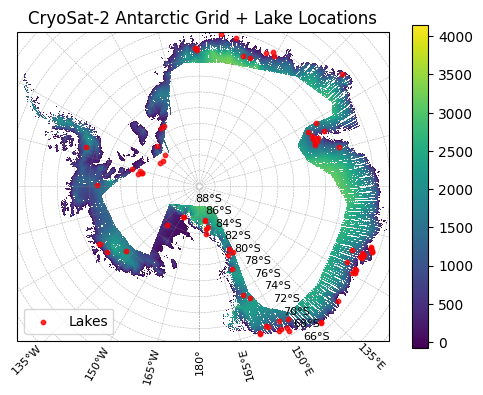

In [9]:
# Cartopy plot with latitude/longitude gridlines
import cartopy.crs as ccrs
from matplotlib.ticker import FixedLocator

fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=ccrs.SouthPolarStereo())

x = var["x"].values
y = var["y"].values
x2d, y2d = np.meshgrid(x, y, indexing="ij")

mesh = ax.pcolormesh(
    x2d,
    y2d,
    var.values,
    transform=ccrs.SouthPolarStereo(),
    cmap="viridis",
    shading="auto",
)

ax.scatter(
    lakes["lon"],
    lakes["lat"],
    s=10,
    c="red",
    alpha=0.8,
    label="Lakes",
    transform=ccrs.PlateCarree(),
)

gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.6,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False
gl.xlocator = FixedLocator(list(range(-180, 181, 15)))
gl.ylocator = FixedLocator(list(range(-90, -59, 2)))
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}

ax.set_title("CryoSat-2 Antarctic Grid + Lake Locations")
ax.legend(loc="lower left")
fig.colorbar(mesh, ax=ax, shrink=0.7)
plt.show()

In [10]:
# Pick 5 CryoSat points away from lakes (lon/lat)
import numpy as np

# Build lon/lat grid from EPSG:3031 coords
x = var["x"].values
y = var["y"].values
xx, yy = np.meshgrid(x, y, indexing="ij")
transformer_ll = Transformer.from_crs("EPSG:3031", "EPSG:4326", always_xy=True)
lon2d, lat2d = transformer_ll.transform(xx, yy)

# Mask valid CryoSat data
valid = np.isfinite(var.values)
lon_valid = lon2d[valid]
lat_valid = lat2d[valid]

# Haversine distance (km)
def haversine_km(lon1, lat1, lon2, lat2):
    r = 6371.0
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return r * c

# Require points at least 50 km from any lake
min_km = 50.0
lons = lakes["lon"].values
lats = lakes["lat"].values

# Randomly sample until we have 5 points
rng = np.random.default_rng(42)
idx = rng.permutation(lon_valid.size)
picked = []
for i in idx:
    lon_p = lon_valid[i]
    lat_p = lat_valid[i]
    d = haversine_km(lon_p, lat_p, lons, lats)
    if np.all(d >= min_km):
        picked.append((lon_p, lat_p))
    if len(picked) == 20:
        break

picked

[(np.float64(-71.23016998800442), np.float64(-79.07673791299837)),
 (np.float64(89.29268063145574), np.float64(-70.06549153860145)),
 (np.float64(103.0970525221909), np.float64(-69.38040656886255)),
 (np.float64(117.53607310815717), np.float64(-69.56591642211832)),
 (np.float64(-91.94763622622582), np.float64(-74.12074008707359)),
 (np.float64(91.89169184592542), np.float64(-67.15394940971512)),
 (np.float64(78.89218696434529), np.float64(-70.73287062180867)),
 (np.float64(22.846382487525197), np.float64(-72.05545772904222)),
 (np.float64(100.71576088929838), np.float64(-68.99399081603438)),
 (np.float64(-114.88814984933259), np.float64(-76.69554184999824)),
 (np.float64(64.05698528314078), np.float64(-72.31682038205577)),
 (np.float64(-30.090873429014017), np.float64(-79.25482340122325)),
 (np.float64(-157.46544226590655), np.float64(-78.15308193984445)),
 (np.float64(75.68552963723485), np.float64(-70.41864258275865)),
 (np.float64(114.52411818987275), np.float64(-69.52413587298476))

In [13]:
np.shape(picked)

(20, 2)

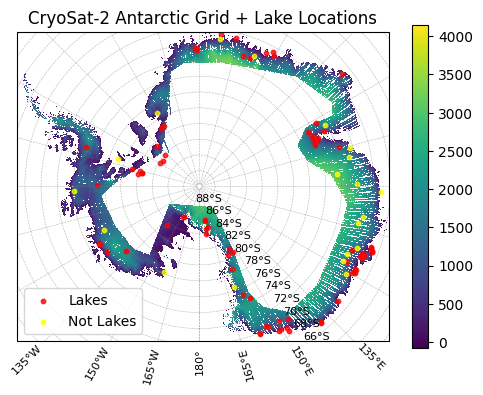

In [16]:
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=ccrs.SouthPolarStereo())

x = var["x"].values
y = var["y"].values
x2d, y2d = np.meshgrid(x, y, indexing="ij")

mesh = ax.pcolormesh(
    x2d,
    y2d,
    var.values,
    transform=ccrs.SouthPolarStereo(),
    cmap="viridis",
    shading="auto",
)

ax.scatter(
    lakes["lon"],
    lakes["lat"],
    s=10,
    c="red",
    alpha=0.8,
    label="Lakes",
    transform=ccrs.PlateCarree(),
)
picked = np.array(picked)
ax.scatter(
    picked[:,0],
    picked[:,1],
    s=10,
    c="yellow",
    alpha = 0.8,
    label = "Not Lakes",
    transform=ccrs.PlateCarree(),
)

gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.6,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False
gl.xlocator = FixedLocator(list(range(-180, 181, 15)))
gl.ylocator = FixedLocator(list(range(-90, -59, 2)))
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}
ax.set_title("CryoSat-2 Antarctic Grid + Lake Locations")
ax.legend(loc="lower left")
fig.colorbar(mesh, ax=ax, shrink=0.7)
plt.show()

In [17]:
root = Path(".").resolve()
project_root = root if (root / "Notebooks").exists() else root.parent
notebook_path = project_root / "Notebooks" / "3.2_DataGrabberLoop.ipynb"
out_dir = project_root / "Subglacial_Lakes_Data"
out_csv = out_dir / "lake_locations.csv"


# Load existing CSV
df = pd.read_csv(out_csv)

# Number of new points
n_new = picked.shape[0]

# Create names
new_names = [f"null_{i}" for i in range(n_new)]

# Create new DataFrame
new_df = pd.DataFrame({
    "name": new_names,
    "lon": picked[:, 0],
    "lat": picked[:, 1]
})

# Append to existing dataframe
df_updated = pd.concat([df, new_df], ignore_index=True)

# Save back to CSV
df_updated.to_csv(out_dir/"lake_and_null_loc.csv", index=False)